In [1]:
import os
import matplotlib.pyplot as plt
import sympy as sp
import numpy as np
import pandas as pd

In [2]:
sheet= pd.read_excel(r'C:\Users\neftid\Desktop\These\IJPR\use_case_data.xlsx', sheet_name=None)

In [7]:
A0 = sheet["A0"].iloc[:, 1:].to_numpy() # ideal linear scenario
A0

array([[    0,     0,  1000],
       [    0,  1000, -1000],
       [ 1000, -1000,     0]], dtype=int64)

In [8]:
A1 = sheet["A1"].iloc[:, 1:].to_numpy() #linear scenario
A1

array([[    0.  ,     0.  ,  1000.  ],
       [    0.  ,  1000.  , -1310.  ],
       [ 1000.  , -1040.01,     0.  ]])

In [9]:
A2 = sheet["A2"].iloc[:, 1:].to_numpy() #ciruclar scenario
A2 


array([[    0.        ,     0.        ,  1000.        ,     0.        ,
            0.        ],
       [    0.        ,  1000.        , -1310.        ,     0.        ,
            0.        ],
       [    0.        ,     0.        ,   308.        ,  -308.        ,
            0.        ],
       [    0.        ,  -235.11450382,     0.        ,   308.        ,
            0.        ],
       [ 1000.        ,  -743.6       ,     0.        ,     0.        ,
            0.        ],
       [    0.        ,   -61.3       ,     0.        ,     0.        ,
          100.        ]])

In [10]:
B0 = sheet["B0"].iloc[:, 1:].to_numpy() # ideal linear scenario

In [11]:
B1=sheet["B1"].iloc[:, 1:].to_numpy() #linear scenario

In [12]:
B2=sheet["B2"].iloc[:, 1:].to_numpy() #circular scenario

In [13]:
C=sheet["C"].iloc[:, 1:].to_numpy()

In [14]:
F0=sheet["F0"].iloc[:, 1:].to_numpy()
F0

array([[1000],
       [   0],
       [   0]], dtype=int64)

In [15]:
F=sheet["F"].iloc[:, 1:].to_numpy()
F

array([[1000],
       [   0],
       [   0],
       [   0],
       [   0],
       [   0]], dtype=int64)

In [16]:
def scaling(A, F):
    A = sp.Matrix(A)
    F = sp.Matrix(F)

    if A.rows != F.rows:
        raise ValueError(
            "The number of rows in the technosphere matrix 'A' must be equal to the number of rows in vector demand 'F'."
        )

    variables = sp.symbols(f"s1:{A.cols + 1}")
    sol = sp.linsolve((A, F), *variables)
    
    if not sol:
        raise ValueError("No solution found for the scaling system.")
    
    sol_tuple = list(sol)[0]
    if any(isinstance(x, sp.Basic) and x.free_symbols for x in sol_tuple):
        raise ValueError("The system has infinit solutions.")
    return np.array(sol_tuple, dtype=float)

In [17]:
s0=scaling(A0, F0)

In [18]:
s1=scaling(A1, F0)

In [19]:
s2=scaling(A2, F)

In [20]:
def L(C,B,s):
    s = np.array(s, dtype=float).reshape(-1)
    Q=np.dot(C,B)
    return np.dot(Q,s)

In [21]:
h0=L(C,B0,s0)
h0

array([7.75808960e+02, 1.44165463e+01, 4.19828188e+00, 3.16510000e+00,
       3.19141200e+00, 3.73400000e-05, 1.26000000e+05, 1.95146400e+03,
       0.00000000e+00])

In [22]:
h1=L(C,B1,s1)
h1

array([9.15870012e+02, 1.96385900e+01, 5.71896937e+00, 4.29119695e+00,
       4.31874337e+00, 4.62370000e-05, 1.71664051e+05, 2.65870012e+03,
       3.62413100e+02])

In [23]:
h2=L(C,B2,s2)
h2

array([8.83715533e+02, 1.41121837e+01, 4.11032182e+00, 3.22228015e+00,
       3.25024174e+00, 4.62370000e-05, 1.23705738e+05, 2.02002819e+03,
       5.44131000e+01])

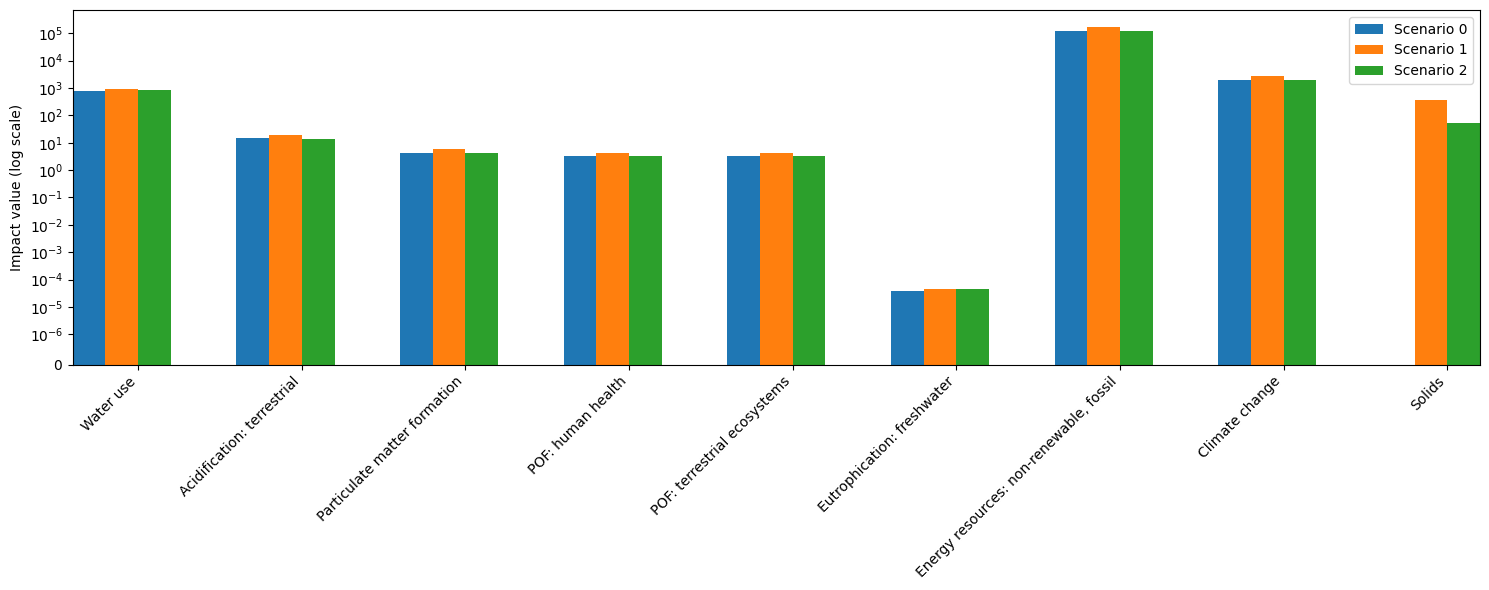

In [52]:
categories = [
    "Water use",
    "Acidification: terrestrial",
    "Particulate matter formation",
    "POF: human health",
    "POF: terrestrial ecosystems",
    "Eutrophication: freshwater",
    "Energy resources: non-renewable, fossil",
    "Climate change",
    "Solids"
]
x = np.arange(len(categories))
width = 0.2

fig, ax = plt.subplots(figsize=(15, 6))
ax.bar(x - 1.5*width, h0, width, label="Scenario 0")
ax.bar(x - 0.5*width, h1, width, label="Scenario 1")
ax.bar(x + 0.5*width, h2, width, label="Scenario 2")
ax.set_ylabel("Impact value (log scale)")
ax.set_yscale("symlog", linthresh=1e-6)
ax.set_xticks(x)
ax.set_xticklabels(categories, rotation=45, ha="right")
ax.legend()
plt.tight_layout()
ax.autoscale(enable=True, axis='x', tight=True)
plt.savefig("impact_fresult.png", dpi=300, bbox_inches='tight', pad_inches=0.05)
plt.show()

In [54]:
process_names_0 = [r"P_{0,1}", r"P_{1,1}", r"P_{2,1}"]      
process_names_1 = [r"P_{0,1}", r"P_{1,1}", r"P_{2,1}"]     
process_names_2 = [
    r"P_{0,1}", r"P_{1,1}", r"P_{2,1}", r"S_{2,1}", r"R_{1,1}"
]

In [55]:
def contribution_analysis(C, B, s,process_names):
    if B.shape[1] != s.shape[0]:
        raise ValueError(f"B has {B.shape[1]} process columns but s has {s.shape[0]} elements.")
    if C.shape[1] != B.shape[0]:
        raise ValueError(f"C has {C.shape[1]} flow columns but B has {B.shape[0]} flow rows.")

    scaled_inventory = B * s
    impact_contributions = C @ scaled_inventory    
    impact_contributions_df = pd.DataFrame(
        impact_contributions,
        index=categories,       
        columns=process_names
    )
    return scaled_inventory, impact_contributions_df

In [56]:
scenarios = {
    "Scenario 0": (B0, s0, process_names_0),
    "Scenario 1": (B1, s1, process_names_1),
    "Scenario 2": (B2, s2, process_names_2),
}
results = {
    name: contribution_analysis(C, B, s, proc_names)
    for name, (B, s, proc_names) in scenarios.items()
}

pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
pd.set_option('display.width', 160)

for name, (scaled_inv, impacts_df) in results.items():
    print(f"\n===== {name} — Process contribution =====")
    print(impacts_df)


===== Scenario 0 — Process contribution =====
                                             P_{0,1}  P_{1,1}  P_{2,1}
Water use                                    82.8090 355.0000 338.0000
Acidification: terrestrial                   14.3845   0.0287   0.0033
Particulate matter formation                  4.1885   0.0088   0.0010
POF: human health                             3.0346   0.0849   0.0456
POF: terrestrial ecosystems                   3.0346   0.0889   0.0679
Eutrophication: freshwater                    0.0000   0.0000   0.0000
Energy resources: non-renewable, fossil 126,000.0000   0.0000   0.0000
Climate change                            1,951.4640   0.0000   0.0000
Solids                                        0.0000   0.0000   0.0000

===== Scenario 1 — Process contribution =====
                                             P_{0,1}  P_{1,1}  P_{2,1}
Water use                                   112.8200 465.0500 338.0000
Acidification: terrestrial                   19.5977  